<a href="https://colab.research.google.com/github/parsasafaie/ImagePRO/blob/main/trained_models/MNIST_cnn_image_classifier/MNIST_cnn_image_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install numpy matplotlib  tensorflow

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras import models, layers, datasets
import tensorflow as tf

In [3]:
(x_train, y_train), (x_test, y_test) = datasets.mnist.load_data()
x_train = x_train / 255.0
x_test = x_test / 255.0

In [4]:
class_names = [i for i in range(10)]

In [5]:
model = models.Sequential([
    layers.Input((28,28,1)),

    layers.Conv2D(32, (3,3), activation="relu", padding='same'),
    layers.MaxPool2D((2,2)),
    layers.BatchNormalization(),

    layers.Conv2D(64, (3,3), activation="relu", padding='same'),
    layers.MaxPool2D((2,2)),
    layers.BatchNormalization(),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.8),
    layers.Dense(10, activation="softmax")
])


In [6]:
model.compile(optimizer='adam',
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 14, 14, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 7, 7, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 422,026 (1.61 MB)

 Trainable params: 421,834 (1.61 MB)

 Non-trainable params: 192 (768.00 B)

In [7]:
model.fit(x_train, y_train, epochs=5, validation_data=(x_test, y_test))

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 57s 29ms/step - accuracy: 0.6060 - loss: 1.1359 - val_accuracy: 0.9764 - val_loss: 0.0811
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 60s 32ms/step - accuracy: 0.8724 - loss: 0.3838 - val_accuracy: 0.9867 - val_loss: 0.0446
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 75s 28ms/step - accuracy: 0.9203 - loss: 0.2348 - val_accuracy: 0.9868 - val_loss: 0.0482
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 28ms/step - accuracy: 0.9393 - loss: 0.1917 - val_accuracy: 0.9895 - val_loss: 0.0358
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 83s 29ms/step - accuracy: 0.9484 - loss: 0.1625 - val_accuracy: 0.9897 - val_loss: 0.0334


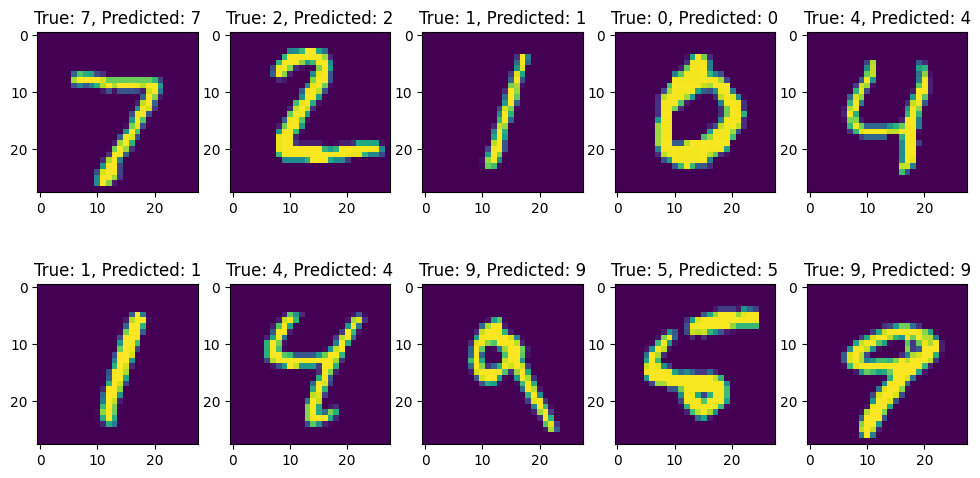

In [8]:
predicted_probs = model.predict(x_test[:10], verbose=0)
predicted_labels = np.argmax(predicted_probs, axis=1)
plt.figure(figsize=((12,6)))
for i in range(10):
  plt.subplot(2,5,i+1)
  plt.imshow(x_test[i])
  plt.title(f"True: {class_names[y_test[i]]}, Predicted: {class_names[predicted_labels[i]]}")
plt.show()

In [9]:
model.save('MNIST_cnn_image_classifier.keras')